In [1]:
!pip install torch torchaudio transformers accelerate evaluate -q

In [2]:
import os
import glob
import numpy as np
import pandas as pd

import librosa
import librosa.display

from tqdm import tqdm


import torch
from torch.utils.data import Dataset
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# SECTION : Dataset Config

DATA_PATH = "/Users/cryptelle/Downloads/remake"

TARGET_SR = 16000
TARGET_SEC = 3
TARGET_LEN = TARGET_SR * TARGET_SEC

TOP_DB = 30
FRAME_LENGTH = 2048
HOP_LENGTH = 512

N_MELS = 128
N_FFT = 1024

In [4]:
# SECTION : Collect WAV Files

wav_paths = glob.glob(
    os.path.join(DATA_PATH, "**", "*.wav"),
    recursive=True
)

wav_files = [
    os.path.basename(f)
    for f in wav_paths
]

print("Total WAV files:", len(wav_paths))
print("First 10 paths:")
print(wav_paths[:10])

Total WAV files: 3870
First 10 paths:
['/Users/cryptelle/Downloads/remake/0/50-f-5-0-2-37.wav', '/Users/cryptelle/Downloads/remake/0/26-m-19-0-0-127.wav', '/Users/cryptelle/Downloads/remake/0/56-f-40-0-2-94.wav', '/Users/cryptelle/Downloads/remake/0/9-f-20-0-1-104.wav', '/Users/cryptelle/Downloads/remake/0/43-m-41-0-1-154.wav', '/Users/cryptelle/Downloads/remake/0/47-m-20-0-2-171.wav', '/Users/cryptelle/Downloads/remake/0/53-m-20-0-2-211.wav', '/Users/cryptelle/Downloads/remake/0/56-f-40-0-0-52.wav', '/Users/cryptelle/Downloads/remake/0/11-m-23-0-0-108.wav', '/Users/cryptelle/Downloads/remake/0/49-m-23-0-2-198.wav']


In [5]:
# SECTION : Labels

def get_emotion(fname):

    base = os.path.splitext(fname)[0]
    parts = base.split("-")

    return int(parts[4])   # spoken_emotion


df = pd.DataFrame({
    "file": wav_files,
    "path": wav_paths
})

df["y"] = df["file"].apply(get_emotion)

EMO_MAP = {
    0: "Low",
    1: "Neutral",
    2: "High"
}

df["emotion_name"] = df["y"].map(EMO_MAP)

df2 = df.copy()
df2["y"] = df2["y"].astype(int)

print(df2["emotion_name"].value_counts())
print(df2.head())

emotion_name
High       1356
Neutral    1344
Low        1170
Name: count, dtype: int64
                  file                                               path  y  \
0    50-f-5-0-2-37.wav  /Users/cryptelle/Downloads/remake/0/50-f-5-0-2...  2   
1  26-m-19-0-0-127.wav  /Users/cryptelle/Downloads/remake/0/26-m-19-0-...  0   
2   56-f-40-0-2-94.wav  /Users/cryptelle/Downloads/remake/0/56-f-40-0-...  2   
3   9-f-20-0-1-104.wav  /Users/cryptelle/Downloads/remake/0/9-f-20-0-1...  1   
4  43-m-41-0-1-154.wav  /Users/cryptelle/Downloads/remake/0/43-m-41-0-...  1   

  emotion_name  
0         High  
1          Low  
2         High  
3      Neutral  
4      Neutral  


In [6]:
# SECTION : Audio Preprocessing

def preprocess_audio(path):

    y, sr = librosa.load(
        path,
        sr=TARGET_SR,
        mono=True
    )

    # Remove silence
    y_trim, _ = librosa.effects.trim(
        y,
        top_db=TOP_DB,
        frame_length=FRAME_LENGTH,
        hop_length=HOP_LENGTH
    )

    # Safety fallback
    if len(y_trim) < 10:
        y_trim = y

    # Normalize
    peak = np.max(np.abs(y_trim)) + 1e-9

    y_trim = y_trim / peak

    # Fixed length
    if len(y_trim) > TARGET_LEN:

        y_trim = y_trim[:TARGET_LEN]

    else:

        y_trim = np.pad(
            y_trim,
            (0, TARGET_LEN - len(y_trim))
        )

    return y_trim

In [7]:
# SECTION : Build Waveforms

X_wave = np.zeros(
    (len(df2), TARGET_LEN),
    dtype=np.float32
)

for i, path in enumerate(
    tqdm(df2["path"], desc="Processing Audio")
):

    X_wave[i] = preprocess_audio(path)

print("X_wave shape:", X_wave.shape)

Processing Audio: 100%|████████████████████| 3870/3870 [00:25<00:00, 151.15it/s]

X_wave shape: (3870, 48000)


In [8]:
X_wave
df2

,file,path,y,emotion_name
0,50-f-5-0-2-37.wav,/Users/cryptelle/Downloads/remake/0/50-f-5-0-2...,2,High
1,26-m-19-0-0-127.wav,/Users/cryptelle/Downloads/remake/0/26-m-19-0-...,0,Low
2,56-f-40-0-2-94.wav,/Users/cryptelle/Downloads/remake/0/56-f-40-0-...,2,High
3,9-f-20-0-1-104.wav,/Users/cryptelle/Downloads/remake/0/9-f-20-0-1...,1,Neutral
4,43-m-41-0-1-154.wav,/Users/cryptelle/Downloads/remake/0/43-m-41-0-...,1,Neutral
...,...,...,...,...
3865,55-m-16-5-0-1560.wav,/Users/cryptelle/Downloads/remake/5/55-m-16-5-...,0,Low
3866,55-m-16-5-1-1574.wav,/Users/cryptelle/Downloads/remake/5/55-m-16-5-...,1,Neutral
3867,50-f-5-5-0-1377.wav,/Users/cryptelle/Downloads/remake/5/50-f-5-5-0...,0,Low
3868,56-f-40-5-2-1455.wav,/Users/cryptelle/Downloads/remake/5/56-f-40-5-...,2,High


In [9]:
y_wav = df2["y"].to_numpy()

X_train_wav, X_temp_wav, y_train_wav, y_temp_wav = train_test_split(
    X_wave,
    y_wav,
    test_size=0.30,
    random_state=42,
    stratify=y_wav
)

X_val_wav, X_test_wav, y_val_wav, y_test_wav = train_test_split(
    X_temp_wav,
    y_temp_wav,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_wav
)

In [10]:
MODEL_NAME = "facebook/wav2vec2-base"

feature_extractor = AutoFeatureExtractor.from_pretrained(
    MODEL_NAME
)

class AudioDataset(Dataset):

    def __init__(self, audio, labels):
        self.audio = audio
        self.labels = labels

    def __len__(self):
        return len(self.audio)

    def __getitem__(self, idx):

        inputs = feature_extractor(
            self.audio[idx],
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        return {
            "input_values": inputs["input_values"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = AudioDataset(X_train_wav, y_train_wav)
val_dataset = AudioDataset(X_val_wav, y_val_wav)
test_dataset = AudioDataset(X_test_wav, y_test_wav)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [11]:
model = AutoModelForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)

model.config.id2label = {
    0: "Low",
    1: "Neutral",
    2: "High"
}

model.config.label2id = {
    "Low": 0,
    "Neutral": 1,
    "High": 2
}

# يخفف التدريب ويقلل استهلاك الذاكرة
model.freeze_feature_encoder()

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc
    }

In [13]:
# ==============================
# SECTION: Wav2Vec2 Training
# ==============================

training_args = TrainingArguments(
    output_dir="./wav2vec2_baved",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    num_train_epochs=10,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    logging_steps=20
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.648349,0.843353,0.686207
2,0.499924,0.511159,0.870690
3,0.334523,0.476324,0.882759
4,0.363006,0.439484,0.906897
5,0.248044,0.422569,0.906897
6,0.244524,0.403069,0.917241
7,0.279443,0.404606,0.927586
8,0.003190,0.389349,0.929310
9,0.062434,0.393144,0.936207
10,0.002473,0.390605,0.932759


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6780, training_loss=0.3313694754043995, metrics={'train_runtime': 4541.0806, 'train_samples_per_second': 5.966, 'train_steps_per_second': 1.493, 'total_flos': 7.3782247974624e+17, 'train_loss': 0.3313694754043995, 'epoch': 10.0})

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Wav2Vec2 Accuracy: 0.9414802065404475

Wav2Vec2 Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.93      0.93       175
     Neutral       0.92      0.92      0.92       202
        High       0.97      0.98      0.97       204

    accuracy                           0.94       581
   macro avg       0.94      0.94      0.94       581
weighted avg       0.94      0.94      0.94       581



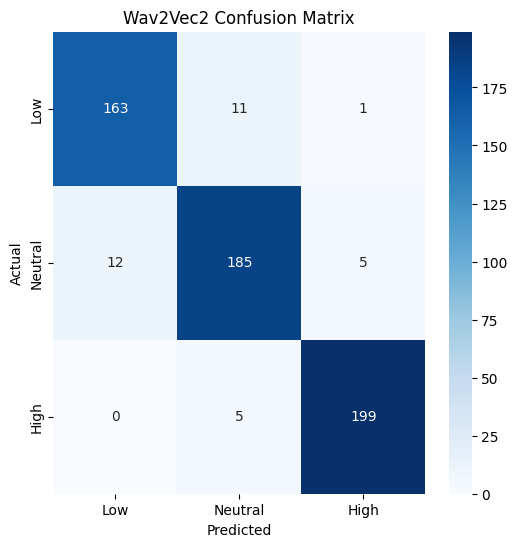

In [16]:
# SECTION: Wav2Vec2 Evaluation

predictions = trainer.predict(
    test_dataset
)

y_pred_wav2vec = np.argmax(
    predictions.predictions,
    axis=1
)

wav2vec_acc = accuracy_score(
    y_test_wav,
    y_pred_wav2vec
)

print(
    "Wav2Vec2 Accuracy:",
    wav2vec_acc
)

print("\nWav2Vec2 Classification Report:")

print(
    classification_report(
        y_test_wav,
        y_pred_wav2vec,
        target_names=[
            "Low",
            "Neutral",
            "High"
        ]
    )
)

# Confusion Matrix
cm_wav2vec = confusion_matrix(
    y_test_wav,
    y_pred_wav2vec
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm_wav2vec,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low",
        "Neutral",
        "High"
    ],
    yticklabels=[
        "Low",
        "Neutral",
        "High"
    ]
)

plt.title("Wav2Vec2 Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
# SECTION: HuBERT Fine-Tuning
HUBERT_MODEL = "facebook/hubert-base-ls960"

In [19]:
hubert_feature_extractor = AutoFeatureExtractor.from_pretrained(
    HUBERT_MODEL
)

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

In [20]:
class HuBERTDataset(Dataset):

    def __init__(self, audio, labels):
        self.audio = audio
        self.labels = labels

    def __len__(self):
        return len(self.audio)

    def __getitem__(self, idx):

        inputs = hubert_feature_extractor(
            self.audio[idx],
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        return {
            "input_values": inputs["input_values"].squeeze(),
            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

hubert_train_dataset = HuBERTDataset(
    X_train_wav,
    y_train_wav
)

hubert_val_dataset = HuBERTDataset(
    X_val_wav,
    y_val_wav
)

hubert_test_dataset = HuBERTDataset(
    X_test_wav,
    y_test_wav
)

In [21]:
hubert_model = AutoModelForAudioClassification.from_pretrained(
    HUBERT_MODEL,
    num_labels=3,
    ignore_mismatched_sizes=True
)

hubert_model.config.id2label = {
    0: "Low",
    1: "Neutral",
    2: "High"
}

hubert_model.config.label2id = {
    "Low": 0,
    "Neutral": 1,
    "High": 2
}

hubert_model.freeze_feature_encoder()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] HubertForSequenceClassification LOAD REPORT from: facebook/hubert-base-ls960
Key               | Status  | 
------------------+---------+-
projector.bias    | MISSING | 
projector.weight  | MISSING | 
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
hubert_training_args = TrainingArguments(

    output_dir="./hubert_baved",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-5,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    num_train_epochs=10,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True,

    logging_steps=20
)

hubert_trainer = Trainer(

    model=hubert_model,

    args=hubert_training_args,

    train_dataset=hubert_train_dataset,

    eval_dataset=hubert_val_dataset,

    compute_metrics=compute_metrics
)

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

In [23]:
hubert_trainer.train()

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.629039,0.570250,0.770690
2,0.675901,0.548428,0.837931
3,0.329847,0.490185,0.881034
4,0.602730,0.412379,0.906897
5,0.204253,0.460426,0.903448
6,0.548344,0.398605,0.920690
7,0.574299,0.398950,0.922414
8,0.295136,0.546967,0.898276
9,0.189353,0.441953,0.915517
10,0.434194,0.442314,0.913793


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6780, training_loss=0.4739736964217329, metrics={'train_runtime': 3924.7716, 'train_samples_per_second': 6.902, 'train_steps_per_second': 1.727, 'total_flos': 7.3782247974624e+17, 'train_loss': 0.4739736964217329, 'epoch': 10.0})

/Users/cryptelle/miniforge3/envs/ser/lib/python3.10/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


HuBERT Accuracy: 0.9104991394148021
              precision    recall  f1-score   support

         Low       0.92      0.90      0.91       175
     Neutral       0.86      0.91      0.88       202
        High       0.96      0.92      0.94       204

    accuracy                           0.91       581
   macro avg       0.91      0.91      0.91       581
weighted avg       0.91      0.91      0.91       581



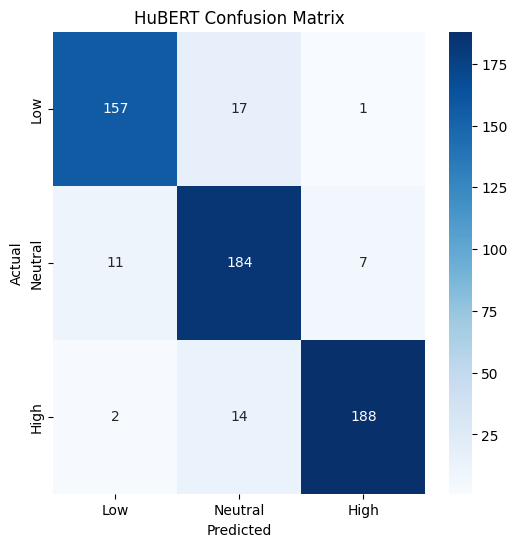

In [26]:
hubert_predictions = hubert_trainer.predict(
    hubert_test_dataset
)

y_pred_hubert = np.argmax(
    hubert_predictions.predictions,
    axis=1
)

hubert_acc = accuracy_score(
    y_test_wav,
    y_pred_hubert
)

print("HuBERT Accuracy:", hubert_acc)

print(
    classification_report(
        y_test_wav,
        y_pred_hubert,
        target_names=[
            "Low",
            "Neutral",
            "High"
        ]
    )
)

# Confusion Matrix
cm_hubert = confusion_matrix(
    y_test_wav,
    y_pred_hubert
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm_hubert,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low",
        "Neutral",
        "High"
    ],
    yticklabels=[
        "Low",
        "Neutral",
        "High"
    ]
)

plt.title("HuBERT Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
# SECTION Augmentation


def add_noise(data, noise_factor=0.005):

    noise = np.random.randn(len(data))

    return data + noise_factor * noise


def shift_pitch(data, sr, n_steps=2):

    return librosa.effects.pitch_shift(
        data,
        sr=sr,
        n_steps=n_steps
    )


def time_shift(data, shift_max=0.2):

    shift = int(
        np.random.uniform(-shift_max, shift_max)
        * len(data)
    )

    return np.roll(data, shift)


def change_volume(data):

    gain = np.random.uniform(0.8, 1.2)

    return data * gain

In [31]:
# SECTION: Log-Mel Extraction


def waveform_to_logmel(y):

    S = librosa.feature.melspectrogram(
        y=y,
        sr=TARGET_SR,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    logS = librosa.power_to_db(
        S,
        ref=np.max
    )

    target_width = 94

    if logS.shape[1] < target_width:

        pad = target_width - logS.shape[1]

        logS = np.pad(
            logS,
            ((0,0),(0,pad)),
            mode='constant'
        )

    else:

        logS = logS[:, :target_width]

    return logS

In [32]:
# SECTION : Feature Extraction


X_mel_list = []
y_augmented = []

for i in tqdm(range(len(df2))):

    y_wave = X_wave[i]

    label = df2["y"].iloc[i]

    # Original
    mel = waveform_to_logmel(y_wave)

    X_mel_list.append(mel)
    y_augmented.append(label)

    # Noise
    noisy = add_noise(y_wave)

    mel_noise = waveform_to_logmel(noisy)

    X_mel_list.append(mel_noise)
    y_augmented.append(label)

    # Pitch Shift
    pitched = shift_pitch(
        y_wave,
        TARGET_SR
    )

    mel_pitch = waveform_to_logmel(pitched)

    X_mel_list.append(mel_pitch)
    y_augmented.append(label)

    # Time Shift
    shifted = time_shift(y_wave)

    mel_shift = waveform_to_logmel(shifted)

    X_mel_list.append(mel_shift)
    y_augmented.append(label)

    # Volume Change
    volume = change_volume(y_wave)

    mel_volume = waveform_to_logmel(volume)

    X_mel_list.append(mel_volume)
    y_augmented.append(label)


X = np.array(
    X_mel_list,
    dtype=np.float32
)

X = X[..., np.newaxis]

y = np.array(y_augmented)

print(X.shape)
print(y.shape)

100%|███████████████████████████████████████| 3870/3870 [01:54<00:00, 33.83it/s]


(19350, 128, 94, 1)
(19350,)


In [37]:

# SECTION: Anxiety-like Clustering Analysis


from sklearn.cluster import KMeans

# Create binary anxiety-style labels
df2["anxiety_label"] = df2["emotion_name"].apply(
    lambda x: "Anxiety-like"
    if x == "High"
    else "Non-Anxiety"
)

# Flatten Mel Spectrograms
X_mel_flattened = X.reshape(
    X.shape[0],
    -1
)

# K-Means with 2 clusters
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

clusters = kmeans.fit_predict(
    X_mel_flattened
)

df2["cluster"] = clusters[:len(df2)]

print("Cluster Distribution:")

print(
    df2["cluster"].value_counts()
)

# Compare clusters with anxiety-style labels
cluster_anxiety = pd.crosstab(
    df2["cluster"],
    df2["anxiety_label"]
)

print(cluster_anxiety)

Cluster Distribution:
cluster
1    2738
0    1132
Name: count, dtype: int64
anxiety_label  Anxiety-like  Non-Anxiety
cluster                                 
0                       418          714
1                       938         1800


In [35]:
trainer.save_model(
    "wav2vec2_baved_model"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [36]:
hubert_trainer.save_model(
    "hubert_baved_model"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]